# Finetuned Model

CLIP failed at zeroshot training which makes sense since it wasn't really trained on typography but I was hoping that other training images depicting emotions and feelings would help it for classifying the feelings associated with fonts. Sort of like how Bouba / Kiki effect where many people across the globe are able to associate Bouba to a round shape and Kiki to a sharp shape despite never hearing these words before.


In [1]:
# Loading Packages
import pandas as pd
from sklearn.metrics import classification_report
from transformers import CLIPProcessor, CLIPModel
from tqdm import tqdm
import os
import numpy as np
import clip
import torch
from PIL import Image
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

c:\Users\windo\Desktop\TheFontinator\datawork\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# IMPORTING CLIP MODEL

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 28345.67it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model.to(device)

Using device: cpu


CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

In [4]:
device.type

'cpu'

In [9]:
# Load your ground truth
gt_df = pd.read_csv("tags/expressive_tags.csv")
gt_df["font"] = gt_df["font"].str.lower().str.replace(" ", "", regex=False)

In [13]:
gt_df

,font,Active,Artistic,Awkward,Business,Calm,Childlike,Competent,Cute,Excited,...,Futuristic,Happy,Innovative,Loud,Playful,Rugged,Sincere,Sophisticated,Stiff,Vintage
0,42dotsans,0.0,0.0,0.0,75.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,40.0,0.0,0.0,0.0,0.0,0.0,0.0
1,abeezee,10.0,0.0,0.0,75.0,91.6,0.0,0.0,0.0,0.0,...,0.0,5.0,0.0,40.0,0.0,0.0,0.0,0.0,0.0,0.0
2,adlamdisplay,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,25.0,0.0,0.0,0.0,0.0,0.0,0.0
3,aronesans,5.0,0.0,0.0,75.0,90.6,0.0,68.0,0.0,0.0,...,0.0,0.0,0.0,40.0,0.0,0.0,0.0,0.0,0.0,0.0
4,abel,10.0,0.0,0.0,0.0,83.4,0.0,19.0,0.0,0.0,...,10.0,0.0,0.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1896,zeyada,20.0,71.0,55.0,0.0,0.0,64.0,0.0,0.0,0.0,...,0.0,30.0,0.0,10.0,34.0,0.0,97.0,0.0,0.0,0.0
1897,zhimangxing,67.0,67.0,0.0,0.0,0.0,0.0,0.0,23.0,0.0,...,0.0,25.0,0.0,50.0,0.0,0.0,0.0,0.0,0.0,0.0
1898,zillaslab,0.0,0.0,0.0,88.5,0.0,0.0,0.0,0.0,0.0,...,0.0,20.0,0.0,40.0,0.0,0.0,0.0,0.0,72.0,28.0
1899,zillaslabhighlight,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,20.0,12.0,20.0,0.0,0.0,0.0,0.0,10.0,0.0


In [14]:
melt = gt_df.melt(id_vars = 'font')

In [15]:
melt

,font,variable,value
0,42dotsans,Active,0.0
1,abeezee,Active,10.0
2,adlamdisplay,Active,10.0
3,aronesans,Active,5.0
4,abel,Active,10.0
...,...,...,...
38015,zeyada,Vintage,0.0
38016,zhimangxing,Vintage,0.0
38017,zillaslab,Vintage,28.0
38018,zillaslabhighlight,Vintage,0.0


In [16]:
tag_counts = melt[melt['value'] != 0.0].value_counts('variable').sort_index().to_numpy()

In [17]:
gt_df.head()

,font,Active,Artistic,Awkward,Business,Calm,Childlike,Competent,Cute,Excited,...,Futuristic,Happy,Innovative,Loud,Playful,Rugged,Sincere,Sophisticated,Stiff,Vintage
0,42dotsans,0.0,0.0,0.0,75.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,40.0,0.0,0.0,0.0,0.0,0.0,0.0
1,abeezee,10.0,0.0,0.0,75.0,91.6,0.0,0.0,0.0,0.0,...,0.0,5.0,0.0,40.0,0.0,0.0,0.0,0.0,0.0,0.0
2,adlamdisplay,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,25.0,0.0,0.0,0.0,0.0,0.0,0.0
3,aronesans,5.0,0.0,0.0,75.0,90.6,0.0,68.0,0.0,0.0,...,0.0,0.0,0.0,40.0,0.0,0.0,0.0,0.0,0.0,0.0
4,abel,10.0,0.0,0.0,0.0,83.4,0.0,19.0,0.0,0.0,...,10.0,0.0,0.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0


In [18]:
# PREPARING DATA

classes = [
    'Active','Artistic','Awkward','Business','Calm','Childlike','Competent','Cute','Excited','Fancy',
    'Futuristic','Happy','Innovative','Loud','Playful','Rugged','Sincere','Sophisticated','Stiff','Vintage'
]


tag_cols = classes
image_dir = "font-photos"

# Build image path list and label matrix
image_paths = []
labels = []

for fname in os.listdir(image_dir):
    if fname.endswith(".png"):
        font_name = fname.replace(".png", "").lower().replace(" ", "")
        match = gt_df[gt_df["font"] == font_name]
        if not match.empty:
            image_paths.append(os.path.join(image_dir, fname))
            labels.append(match[tag_cols].values[0])

labels = np.array(labels, dtype=np.float32)

# Normalize labels to 0-1 if they aren't already (gt is scaled 1-100)
# labels = labels / (labels.max(axis=1, keepdims=True) + 1e-8)

# Instead of normalizing to 0-1 try using hard values so that the model fits on a slider better
labels = (labels > 0).astype(np.float32)  # hard 0 or 1

# Train/val split
train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths, labels, test_size=0.2, random_state=42
)

In [19]:
# FINE TUNING
_, preprocess = clip.load("ViT-B/32", device=device.type)

class FontTagDataset(Dataset):
    def __init__(self, image_paths, labels):
        self.image_paths = image_paths
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = preprocess(Image.open(self.image_paths[idx]).convert("RGB"))
        return image, self.labels[idx]

pos_weights = torch.tensor(1 / tag_counts * tag_counts.mean(), 
                           dtype=torch.float32).to(device)

train_dataset = FontTagDataset(train_paths, train_labels)
val_dataset   = FontTagDataset(val_paths, val_labels)

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataloader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)

In [20]:
model, _ = clip.load("ViT-B/32", device=device)

# Freeze CLIP backbone, only train the head
for param in model.parameters():
    param.requires_grad = False

# Small MLP head on top of CLIP image embeddings
class CLIPWithHead(nn.Module):
    def __init__(self, clip_model, num_tags):
        super().__init__()
        self.clip = clip_model
        self.head = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_tags)  # no sigmoid — BCEWithLogitsLoss handles it
        )

    def forward(self, images):
        with torch.no_grad():  # frozen backbone
            features = self.clip.encode_image(images).float()
        return self.head(features)

clf_model = CLIPWithHead(model, num_tags=len(tag_cols)).to(device)

In [25]:
optimizer = torch.optim.Adam(clf_model.head.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()#pos_weight=pos_weights) # TODO: TRY REMOVING WEIGHT IT MIGHT BE OVERCORRECTING

num_epochs = 10

for epoch in range(num_epochs):
    # --- Train ---
    clf_model.train()
    train_loss = 0
    for images, labels in tqdm(train_dataloader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = clf_model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # --- Validate ---
    clf_model.eval()
    val_loss = 0
    with torch.no_grad():
        for images, labels in val_dataloader:
            images, labels = images.to(device), labels.to(device)
            logits = clf_model(images)
            val_loss += criterion(logits, labels).item()

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss/len(train_dataloader):.4f} | "
          f"Val Loss: {val_loss/len(val_dataloader):.4f}")

torch.save(clf_model.state_dict(), "clip_finetuned_hard_labels.pt")

100%|██████████| 29/29 [00:58<00:00,  2.02s/it]


Epoch 1/10 | Train Loss: 0.4167 | Val Loss: 0.3742


100%|██████████| 29/29 [00:59<00:00,  2.05s/it]


Epoch 2/10 | Train Loss: 0.3841 | Val Loss: 0.3555


100%|██████████| 29/29 [01:03<00:00,  2.19s/it]


...

Epoch 8/10 | Train Loss: 0.3120 | Val Loss: 0.3119


100%|██████████| 29/29 [01:17<00:00,  2.68s/it]


Epoch 9/10 | Train Loss: 0.3010 | Val Loss: 0.3097


100%|██████████| 29/29 [01:16<00:00,  2.65s/it]


Epoch 10/10 | Train Loss: 0.2968 | Val Loss: 0.3026


In [26]:
# Try this later

In [27]:
clf_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_dataloader:
        images = images.to(device)
        logits = clf_model(images)
        probs = torch.sigmoid(logits).cpu().numpy()
        all_preds.append(probs)
        all_labels.append(labels.numpy())

all_preds  = np.vstack(all_preds)
all_labels = np.vstack(all_labels)

In [28]:
pred_binary = (all_preds > 0).astype(int)
gt_binary   = (all_labels > 0).astype(int)

print(classification_report(gt_binary, pred_binary, target_names=tag_cols))

               precision    recall  f1-score   support

       Active       0.33      1.00      0.50        75
     Artistic       0.19      1.00      0.32        43
      Awkward       0.08      1.00      0.14        17
     Business       0.50      1.00      0.67       114
         Calm       0.26      1.00      0.41        59
    Childlike       0.08      1.00      0.16        19
    Competent       0.23      1.00      0.37        51
         Cute       0.14      1.00      0.25        32
      Excited       0.10      1.00      0.18        23
        Fancy       0.09      1.00      0.17        21
   Futuristic       0.19      1.00      0.33        44
        Happy       0.46      1.00      0.63       103
   Innovative       0.08      1.00      0.14        17
         Loud       0.92      1.00      0.96       209
      Playful       0.19      1.00      0.33        44
       Rugged       0.06      1.00      0.11        13
      Sincere       0.27      1.00      0.43        61
Sophistic

In [29]:
pred_binary = (all_preds > 0.7).astype(int)
gt_binary   = (all_labels > 0.7).astype(int)

print(classification_report(gt_binary, pred_binary, target_names=tag_cols))

               precision    recall  f1-score   support

       Active       0.82      0.24      0.37        75
     Artistic       0.96      0.51      0.67        43
      Awkward       1.00      0.06      0.11        17
     Business       0.85      0.73      0.78       114
         Calm       0.82      0.71      0.76        59
    Childlike       0.00      0.00      0.00        19
    Competent       1.00      0.02      0.04        51
         Cute       0.00      0.00      0.00        32
      Excited       1.00      0.04      0.08        23
        Fancy       0.93      0.62      0.74        21
   Futuristic       0.70      0.16      0.26        44
        Happy       0.94      0.45      0.61       103
   Innovative       0.50      0.06      0.11        17
         Loud       0.97      0.98      0.97       209
      Playful       1.00      0.02      0.04        44
       Rugged       0.00      0.00      0.00        13
      Sincere       0.80      0.20      0.32        61
Sophistic

c:\Users\windo\Desktop\TheFontinator\datawork\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [30]:
train_dataset_df = pd.DataFrame({
    'path': train_paths,
    'labels': list(train_labels)
})

label_matrix = np.array(train_labels)

print("Tag counts in training set:")
for i, tag in enumerate(tag_cols):
    count = (label_matrix[:, i] > 0).sum()
    print(f"{tag:<20} {count}")

Tag counts in training set:
Active               249
Artistic             161
Awkward              111
Business             454
Calm                 231
Childlike            72
Competent            169
Cute                 127
Excited              116
Fancy                68
Futuristic           219
Happy                423
Innovative           109
Loud                 859
Playful              187
Rugged               73
Sincere              220
Sophisticated        45
Stiff                264
Vintage              393


In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

clf_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_dataloader:
        images = images.to(device)
        logits = clf_model(images)
        probs = torch.sigmoid(logits).cpu().numpy()
        all_preds.append(probs)
        all_labels.append(labels.numpy())

all_preds  = np.vstack(all_preds)
all_labels = np.vstack(all_labels)

print(f"{'Tag':<20} {'MAE':>8} {'MSE':>8} {'RMSE':>8}")
print("-" * 48)
for i, tag in enumerate(tag_cols):
    mae  = mean_absolute_error(all_labels[:, i], all_preds[:, i])
    mse  = mean_squared_error(all_labels[:, i], all_preds[:, i])
    rmse = np.sqrt(mse)
    print(f"{tag:<20} {mae:>8.4f} {mse:>8.4f} {rmse:>8.4f}")

print("-" * 48)
overall_mae  = mean_absolute_error(all_labels, all_preds)
overall_mse  = mean_squared_error(all_labels, all_preds)
print(f"{'Overall':<20} {overall_mae:>8.4f} {overall_mse:>8.4f} {np.sqrt(overall_mse):>8.4f}")

Tag                       MAE      MSE     RMSE
------------------------------------------------
Active                 0.3209   0.1593   0.3991
Artistic               0.1392   0.0658   0.2566
Awkward                0.1307   0.0590   0.2430
Business               0.2518   0.1267   0.3560
Calm                   0.1853   0.0847   0.2911
Childlike              0.1220   0.0663   0.2575
Competent              0.2904   0.1356   0.3682
Cute                   0.2166   0.1075   0.3279
Excited                0.1588   0.0834   0.2887
Fancy                  0.0603   0.0268   0.1637
Futuristic             0.2104   0.1057   0.3250
Happy                  0.3201   0.1435   0.3788
Innovative             0.1051   0.0631   0.2511
Loud                   0.0781   0.0458   0.2140
Playful                0.2393   0.1300   0.3606
Rugged                 0.1045   0.0544   0.2333
Sincere                0.2712   0.1280   0.3577
Sophisticated          0.0654   0.0335   0.1831
Stiff                  0.3212   0.1542 

In [32]:
all_preds

array([[6.69549286e-01, 5.57697654e-01, 3.39561522e-01, ...,
        5.42470627e-02, 6.21624887e-02, 5.14194608e-01],
       [1.14718646e-01, 9.49487928e-03, 2.73898039e-02, ...,
        5.45869465e-04, 4.78885144e-01, 1.83231965e-01],
       [7.45861530e-01, 8.87262583e-01, 2.22143039e-01, ...,
        2.56137878e-01, 1.34546105e-02, 8.32653761e-01],
       ...,
       [7.58856535e-01, 9.29208875e-01, 2.79927850e-02, ...,
        6.28629923e-01, 5.80442231e-03, 9.79016960e-01],
       [1.29003733e-01, 2.12958567e-02, 3.16802114e-02, ...,
        1.90560508e-03, 3.16854179e-01, 4.90430802e-01],
       [4.46594983e-01, 1.16198219e-01, 1.44892201e-01, ...,
        4.72559873e-03, 2.33070031e-01, 4.93148506e-01]],
      shape=(226, 20), dtype=float32)

In [33]:
gt_binary   = (all_labels > 0.7).astype(int)

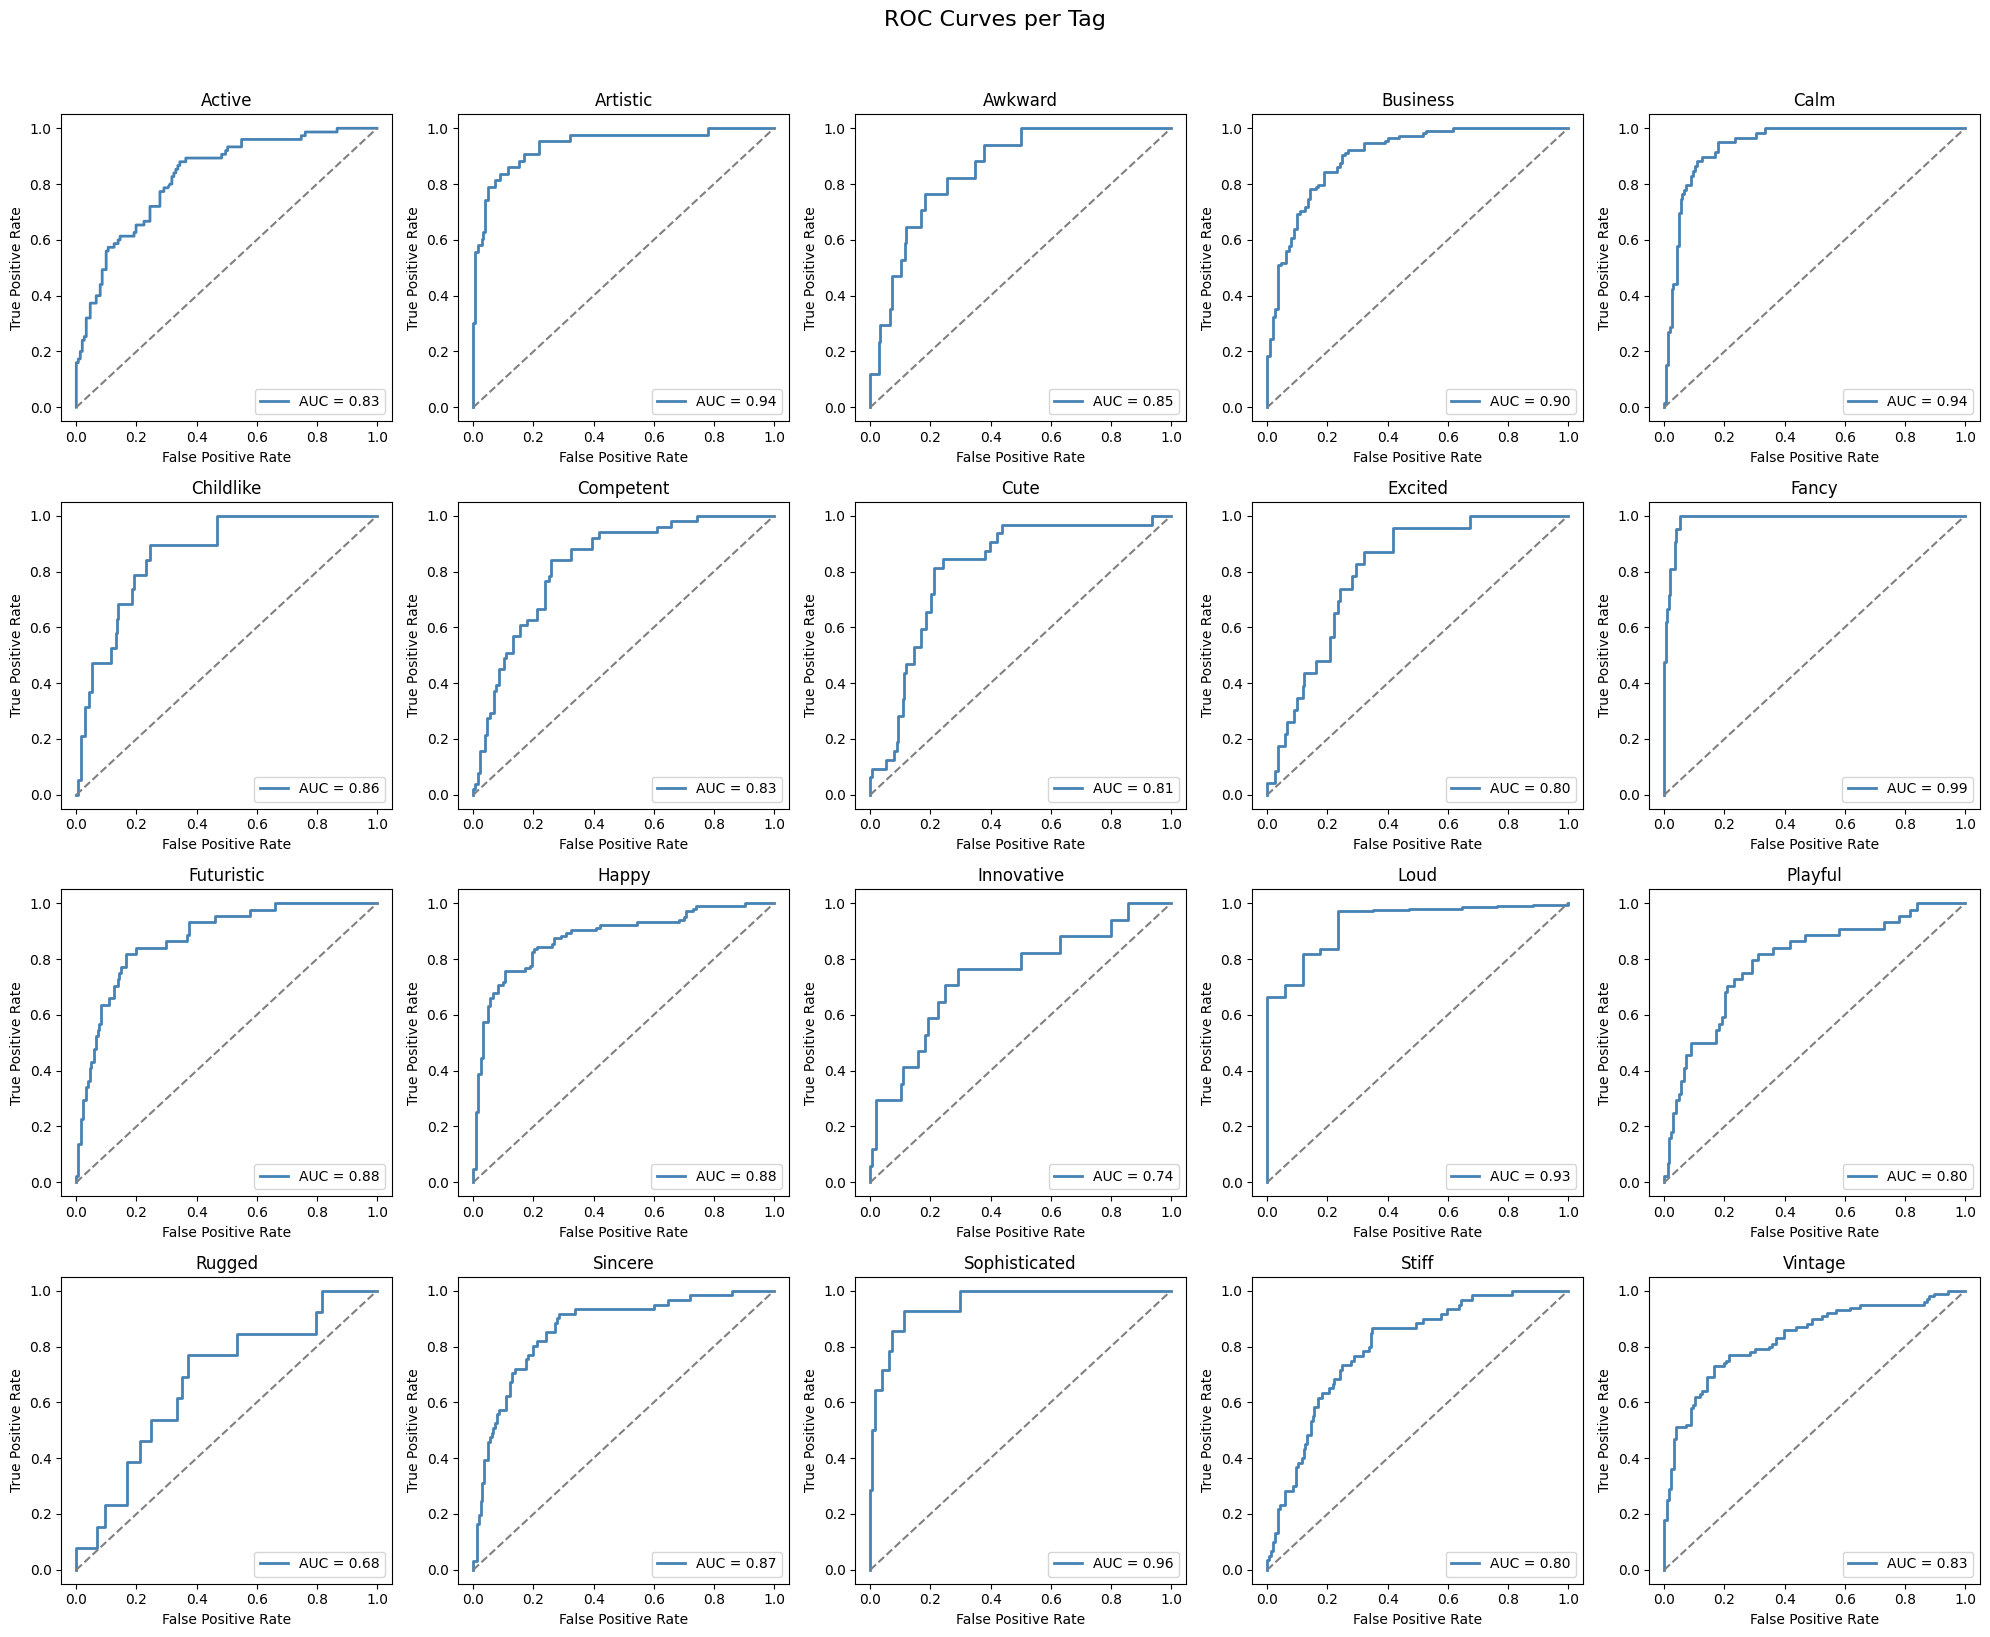

In [34]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 5, figsize=(20, 16))
axes = axes.flatten()

for i, tag in enumerate(tag_cols):
    fpr, tpr, _ = roc_curve(gt_binary[:, i], all_preds[:, i])
    roc_auc = auc(fpr, tpr)
    
    axes[i].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {roc_auc:.2f}')
    axes[i].plot([0, 1], [0, 1], color='grey', linestyle='--')
    axes[i].set_title(tag)
    axes[i].set_xlabel('False Positive Rate')
    axes[i].set_ylabel('True Positive Rate')
    axes[i].legend(loc='lower right')

plt.suptitle('ROC Curves per Tag', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('roc_curves.png', bbox_inches='tight')
plt.show()

In [35]:
optimal_thresholds = {}

print(f"{'Tag':<20} {'AUC':>6} {'Threshold':>10}")
print("-" * 40)

for i, tag in enumerate(tag_cols):
    fpr, tpr, thresholds = roc_curve((all_labels[:, i] > 0.7).astype(int), all_preds[:, i])
    roc_auc = auc(fpr, tpr)
    
    # Youden's J — maximizes (sensitivity + specificity)
    j_scores = tpr - fpr
    best_threshold = thresholds[np.argmax(j_scores)]
    optimal_thresholds[tag] = best_threshold
    
    print(f"{tag:<20} {roc_auc:>6.3f} {best_threshold:>10.3f}")

# Now use these thresholds for classification
pred_binary_optimal = np.array([
    (all_preds[:, i] >= optimal_thresholds[tag]).astype(int)
    for i, tag in enumerate(tag_cols)
]).T

print("\nClassification report with optimal thresholds:")
print(classification_report(
    (all_labels > 0.7).astype(int), 
    pred_binary_optimal, 
    target_names=tag_cols
))

Tag                     AUC  Threshold
----------------------------------------
Active                0.827      0.208
Artistic              0.940      0.196
Awkward               0.855      0.134
Business              0.901      0.551
Calm                  0.942      0.436
Childlike             0.865      0.063
Competent             0.828      0.306
Cute                  0.812      0.142
Excited               0.802      0.089
Fancy                 0.989      0.155
Futuristic            0.875      0.243
Happy                 0.880      0.449
Innovative            0.744      0.039
Loud                  0.930      0.805
Playful               0.795      0.127
Rugged                0.679      0.047
Sincere               0.866      0.202
Sophisticated         0.956      0.043
Stiff                 0.797      0.272
Vintage               0.833      0.509

Classification report with optimal thresholds:
               precision    recall  f1-score   support

       Active       0.56      0.88  

In [36]:
results = []

for i, tag in enumerate(tag_cols):
    fpr, tpr, thresholds = roc_curve((all_labels[:, i] > 0).astype(int), all_preds[:, i])
    roc_auc = auc(fpr, tpr)
    
    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    best_threshold = thresholds[best_idx]
    best_tpr = tpr[best_idx]
    best_fpr = fpr[best_idx]
    
    mae  = mean_absolute_error(all_labels[:, i], all_preds[:, i])
    mse  = mean_squared_error(all_labels[:, i], all_preds[:, i])
    rmse = np.sqrt(mse)

    results.append({
        'tag':            tag,
        'auc':            roc_auc,
        'optimal_threshold': best_threshold,
        'tpr_at_threshold':  best_tpr,
        'fpr_at_threshold':  best_fpr,
        'mae':            mae,
        'mse':            mse,
        'rmse':           rmse,
    })

results_df = pd.DataFrame(results).sort_values('rmse', ascending=True)
print(results_df.to_string(index=False))

          tag      auc  optimal_threshold  tpr_at_threshold  fpr_at_threshold      mae      mse     rmse
        Fancy 0.988618           0.155488          1.000000          0.053659 0.060275 0.026797 0.163699
Sophisticated 0.955526           0.043049          0.928571          0.113208 0.065376 0.033516 0.183074
         Loud 0.929918           0.804607          0.971292          0.235294 0.078052 0.045803 0.214017
       Rugged 0.679307           0.047191          0.769231          0.370892 0.104519 0.054406 0.233251
      Awkward 0.854771           0.134155          0.764706          0.181818 0.130711 0.059031 0.242962
   Innovative 0.743597           0.038789          0.764706          0.291866 0.105133 0.063059 0.251116
     Artistic 0.940399           0.195895          0.837209          0.087432 0.139198 0.065832 0.256577
    Childlike 0.864734           0.063361          0.894737          0.246377 0.121966 0.066304 0.257495
      Excited 0.802099           0.088680          0.86

array([[<Axes: title={'center': 'Active'}>,
        <Axes: title={'center': 'Artistic'}>,
        <Axes: title={'center': 'Awkward'}>,
        <Axes: title={'center': 'Business'}>],
       [<Axes: title={'center': 'Calm'}>,
        <Axes: title={'center': 'Childlike'}>,
        <Axes: title={'center': 'Competent'}>,
        <Axes: title={'center': 'Cute'}>],
       [<Axes: title={'center': 'Excited'}>,
        <Axes: title={'center': 'Fancy'}>,
        <Axes: title={'center': 'Futuristic'}>,
        <Axes: title={'center': 'Happy'}>],
       [<Axes: title={'center': 'Innovative'}>,
        <Axes: title={'center': 'Loud'}>,
        <Axes: title={'center': 'Playful'}>,
        <Axes: title={'center': 'Rugged'}>],
       [<Axes: title={'center': 'Sincere'}>,
        <Axes: title={'center': 'Sophisticated'}>,
        <Axes: title={'center': 'Stiff'}>,
        <Axes: title={'center': 'Vintage'}>]], dtype=object)

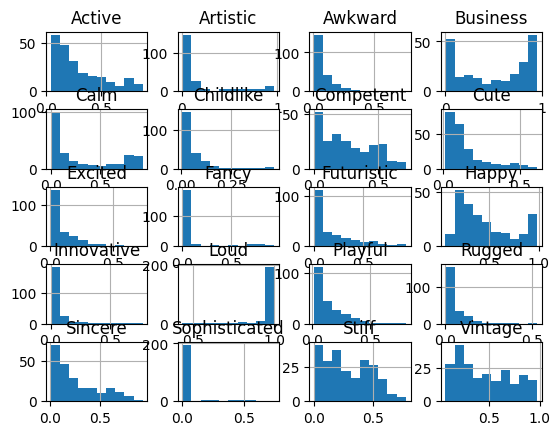

In [38]:
pd.DataFrame(all_preds, columns=classes).replace(0, np.nan).hist()

# Conclusion

After replacing the score ranges between 0-1 with binary 0 and 1 ground truth values, the predictions spread out a lot more (model didn't overfit to guessing some really low number anymore that is moderately close to everything)

This might be better for our validation set but since we fine tuned using part of our dataset that we want to use in the sliders those values have been learned and thus won't be that good on the slider anymore.